# Endelig modellsammenligning: out-of-sample 2024

Fire prismodeller for ren egen-skadepremie (forventet skadekostnad per eksponeringsår)
sammenlignes med en **nullmodell** på ett ubrukt år: **Tweedie-GLM**, **toleddet GLM**
(frekvens × severity), **CatBoost** og en nivåkalibrert variant av CatBoost. Modellene er
spesifisert og refittet på 2022–2023 i egne notebooks (`02_frekvens`, `03_severity`,
`04_tweedie`, `05_catboost`) og lagret i `models/`. Ingen modell trenes eller justeres her.

Usikkerheten måles med en **parvis bootstrap over forsikringstakere** ($B=10\,000$), slik at
alle forskjeller mellom modellene har et intervall og ikke bare et punktestimat.

2024 er ikke brukt til modellvalg, seleksjon eller tuning. Testlåsen er aktiv:
ingen 2024-data leses før `RUN_2024_EVALUATION` og godkjenningskoden bevisst settes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from src_core_glm.model_data import build_development_frames
from src_model_comparison.comparison_plots import (
    plot_model_comparison,
    plot_pairwise_forest,
)
from src_model_comparison.gini_bootstrap import (
    NULL_MODEL,
    build_model_summary,
    build_pairwise_table,
    format_model_summary,
    format_pairwise_table,
    paired_bootstrap,
)
from src_model_comparison.locked_models import load_locked_model
from src_model_comparison.recalibration import estimate_level_factor
from src_model_comparison.test_evaluation import (
    build_approved_test_frame,
    build_calibration_table,
    evaluate_pricing_models,
)

TWEEDIE_POWER = 1.744  # samme avrundede p som i CatBoost og protokollen under
N_BOOT = 10_000  # antall bootstrap-utvalg
RUN_2024_EVALUATION = True  # godkjent av prosjekteier etter at alle modeller er låst
APPROVAL_CODE = "APPROVED_2024_TEST_EVALUATION"

## 1. Modellene

Alle estimerer $\mu_i=E[S_i/e_i]$, forventet skadekostnad per eksponeringsår for
poliseår $i$ med totalkostnad $S_i$ og eksponering $e_i$. Prediktorene er de samme 12
kandidatvariablene i alle modellene; hver modell velger selv hvilke som brukes.

**Nullmodell.** Én flat pris, porteføljens gjennomsnittlige skadekostnad i 2022–2023:

$$
\widehat\mu_0=\frac{\sum_i S_i}{\sum_i e_i}.
$$

Den har ingen rangeringsevne (Gini $=0$) og er referansen for $D^2$ under.

**Tweedie-GLM.** Ren premie modelleres direkte, med log-link og vekt $e_i$:

$$
\frac{S_i}{e_i}\sim\operatorname{Tweedie}\!\left(\mu_i,\tfrac{\phi}{e_i},p\right),
\qquad
\log\mu_i=\beta_0+\gamma^{\mathrm{type}}_i+\gamma^{\mathrm{year}}_i+\gamma^{\mathrm{area}}_i
+\gamma^{\mathrm{pay}}_i+\gamma^{\mathrm{fuel}}_i+\gamma^{\mathrm{seat}}_i+\gamma^{\mathrm{bus}}_i
+\beta_v\log V_i+f_3(\mathrm{age}_i).
$$

**Toleddet GLM.** Frekvens og severity modelleres hver for seg, og premien er produktet:

$$
\widehat R_i=\widehat\lambda_i\,\widehat s_i,
\qquad
\log\lambda_i=\beta_0+\gamma^{\mathrm{type}}_i+\gamma^{\mathrm{year}}_i+\gamma^{\mathrm{area}}_i
+\gamma^{\mathrm{pay}}_i+\gamma^{\mathrm{bus}}_i+\beta_v\log V_i+f_4(\mathrm{age}_i),
$$

$$
\log s_i=\alpha_0+\delta^{\mathrm{type}}_i+\delta^{\mathrm{year}}_i+\delta^{\mathrm{area}}_i
+\delta^{\mathrm{bus}}_i+\alpha_v\log V_i+\alpha_a\,\mathrm{age}_i.
$$

Frekvensen er Poisson (vekt $e_i$), severity er Gamma på poliseår med skade (vekt
antall skader). $f_k$ er en naturlig kubisk spline med $k$ frihetsgrader.

**CatBoost.** Gradientboostede symmetriske trær med log-link og Tweedie-tap:

$$
\widehat\mu(x)=\exp\Big\{\sum_{m=1}^{M}\eta\,t_m(x)\Big\},
$$

med $M$ trær av dybde $d$, læringsrate $\eta$ og $L_2$-regularisering $\lambda$ valgt
ved gruppe-CV (verdiene står i `05_catboost`). Tweedie-GLM og CatBoost bruker
$p=1.744$. Den fullstendige spesifikasjonen (leddene, referansenivåene og antall
parametere) står i hver modellnotebook.

**CatBoost (rekalibrert).** En enkelt nivåfaktor $c$ skalerer alle CatBoost-prediksjoner:

$$
\widetilde\mu(x)=c\,\widehat\mu(x),
\qquad
c=\frac{\sum_i S_i}{\sum_i e_i\,\widehat\mu^{\mathrm{oof}}_i}.
$$

$c$ estimeres kun fra out-of-fold-prediksjonene på 2022–2023 (samme gruppefolder som i
`05_catboost`) og bruker aldri 2024. Rangeringen er uendret, så Gini er identisk med
CatBoost; det som endres er nivået. Varianten er **post hoc**: den ble lagt til etter at
CatBoost var låst, og den erstatter ikke den forhåndsspesifiserte CatBoost-modellen.

In [2]:
# Lås opp de lagrede modellene. Brand-poolingen og nullmodellen læres kun fra 2022–2023.
development_frames = build_development_frames()
development = development_frames["development"]
retained_brands = development_frames["retained_brands"]
frequency_model = load_locked_model("frequency")
severity_model = load_locked_model("severity")
tweedie_model = load_locked_model("tweedie")
catboost_model = load_locked_model("catboost")

null_rate = development["property_incurred"].sum() / development["total_exposure"].sum()
level_factor = estimate_level_factor(catboost_model, development)
print(f"Nullmodell: {null_rate:.1f} EUR per eksponeringsår; nivåfaktor c = {level_factor:.4f}")

prediction_functions = {
    NULL_MODEL: lambda frame: np.full(len(frame), null_rate),
    "Toleddet GLM": lambda frame: frequency_model(frame) * severity_model(frame),
    "Tweedie-GLM": tweedie_model,
    "CatBoost": catboost_model,
    "CatBoost (rekalibrert)": lambda frame: level_factor * catboost_model(frame),
}

Nullmodell: 234.6 EUR per eksponeringsår; nivåfaktor c = 1.0273


## 2. Testprotokoll

Med observert $R_i=S_i/e_i$ og predikert $\widehat R_i$ måles hver modell med:

- **Deviance** (primærmål, lavere er bedre): eksponeringsvektet Tweedie-deviance, $p=1.744$.
- **$D^2$**: andel av nullmodellens deviance som modellen fjerner, $1-D_{\text{modell}}/D_{\text{null}}$.
- **Gini** (rangeringsevne, høyere er bedre): rader sorteres etter predikert risiko, og
  Lorenz-kurven viser kumulativ andel av skadekostnad mot kumulativ andel av eksponering.
  $\text{Gini}=1-2\cdot\text{areal under kurven}$ (Frees, Meyers og Cummings, 2011). Normalisert
  Gini deler på Gini for en perfekt rangering av de observerte utfallene.
- **Balanse**: $\sum_i e_i\widehat R_i\big/\sum_i S_i-1$, og vektet MAE.

**Parvis bootstrap.** Forsikringstakere (`insured_id`) trekkes med tilbakelegging
$B=10\,000$ ganger, slik at flere poliseår for samme kunde følger hverandre. Alle modeller
skåres på nøyaktig samme utvalg, så forskjellene mellom modellene er parvise og tar hensyn
til at prediksjonene henger sammen. Intervallene er 95 %-percentilintervall. For et par
$(A,B)$ er *gevinst* positiv når $A$ er bedre, og $P(A\ \text{bedre})$ er andelen utvalg
der $A$ vinner.

`year` er en låst kategorisk term og 2024 finnes ikke i treningsdata, så alle modeller skåres
med 2023-nivået. Numeriske prediktorer klippes til treningsområdet ved skåring.

In [3]:
if RUN_2024_EVALUATION:
    test_frame = build_approved_test_frame(retained_brands, approval_code=APPROVAL_CODE)
    results, predictions = evaluate_pricing_models(
        test_frame, prediction_functions, power=TWEEDIE_POWER
    )
    boot = paired_bootstrap(
        test_frame, predictions, TWEEDIE_POWER, n_boot=N_BOOT, seed=100
    )
    summary = build_model_summary(results, test_frame, boot)
    model_predictions = {k: v for k, v in predictions.items() if k != NULL_MODEL}
    calibration = build_calibration_table(test_frame, model_predictions)

## 3. Resultater mot nullmodellen

In [4]:
if RUN_2024_EVALUATION:
    display(format_model_summary(summary))

,Devians,D² i % [95 % KI],Gini [95 % KI],Normalisert Gini,Vektet MAE,Balanse i % [95 % KI]
Nullmodell,33.369,0.00 (referanse),0.000 (referanse),0.000,408.9,"-2.6 [-5.9, 0.9]"
Toleddet GLM,32.180,"3.56 [3.17, 3.95]","0.300 [0.279, 0.319]",0.324,398.2,"0.9 [-2.4, 4.4]"
Tweedie-GLM,32.204,"3.49 [3.11, 3.87]","0.298 [0.279, 0.317]",0.322,396.0,"-0.8 [-4.2, 2.6]"
CatBoost,32.213,"3.46 [3.09, 3.85]","0.295 [0.276, 0.315]",0.319,391.4,"-4.0 [-7.2, -0.7]"
CatBoost (rekalibrert),32.214,"3.46 [3.09, 3.84]","0.295 [0.276, 0.315]",0.319,395.6,"-1.4 [-4.7, 2.0]"


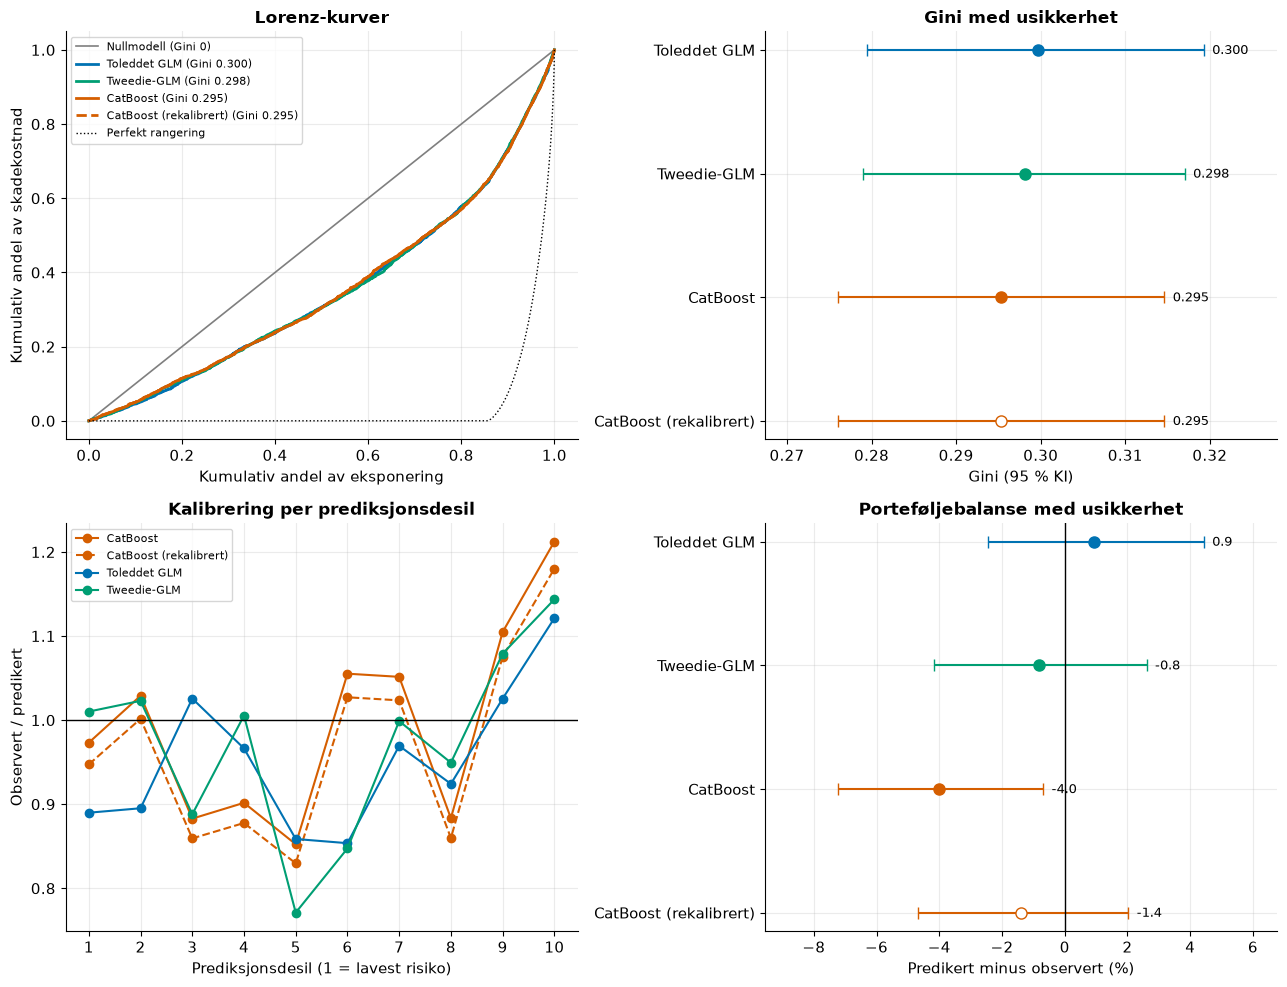

In [5]:
if RUN_2024_EVALUATION:
    figure = plot_model_comparison(test_frame, predictions, calibration, summary)
    display(figure)
    plt.close(figure)

## 4. Parvise sammenligninger

Hver rad sammenligner modell A med modell B på samme bootstrap-utvalg.

In [6]:
PAIRS = [
    ("Tweedie-GLM", "Toleddet GLM"),
    ("CatBoost", "Tweedie-GLM"),
    ("CatBoost", "Toleddet GLM"),
    ("CatBoost (rekalibrert)", "Tweedie-GLM"),
    ("CatBoost (rekalibrert)", "Toleddet GLM"),
    ("CatBoost (rekalibrert)", "CatBoost"),
]
if RUN_2024_EVALUATION:
    pairwise = build_pairwise_table(boot, PAIRS)
    display(format_pairwise_table(pairwise))

,Devians-gevinst [95 % KI],"P(A bedre), devians",Gini-gevinst [95 % KI],"P(A bedre), Gini"
pair,,,,
Tweedie-GLM mot Toleddet GLM,"-0.025 [-0.056, +0.007]",6%,"-0.0015 [-0.0075, +0.0045]",32%
CatBoost mot Tweedie-GLM,"-0.008 [-0.039, +0.022]",29%,"-0.0027 [-0.0076, +0.0023]",14%
CatBoost mot Toleddet GLM,"-0.033 [-0.072, +0.005]",5%,"-0.0043 [-0.0116, +0.0031]",13%
CatBoost (rekalibrert) mot Tweedie-GLM,"-0.009 [-0.038, +0.020]",26%,"-0.0027 [-0.0076, +0.0023]",14%
CatBoost (rekalibrert) mot Toleddet GLM,"-0.034 [-0.072, +0.003]",4%,"-0.0043 [-0.0116, +0.0031]",13%
CatBoost (rekalibrert) mot CatBoost,"-0.001 [-0.009, +0.007]",41%,"+0.0000 [+0.0000, +0.0000]",–


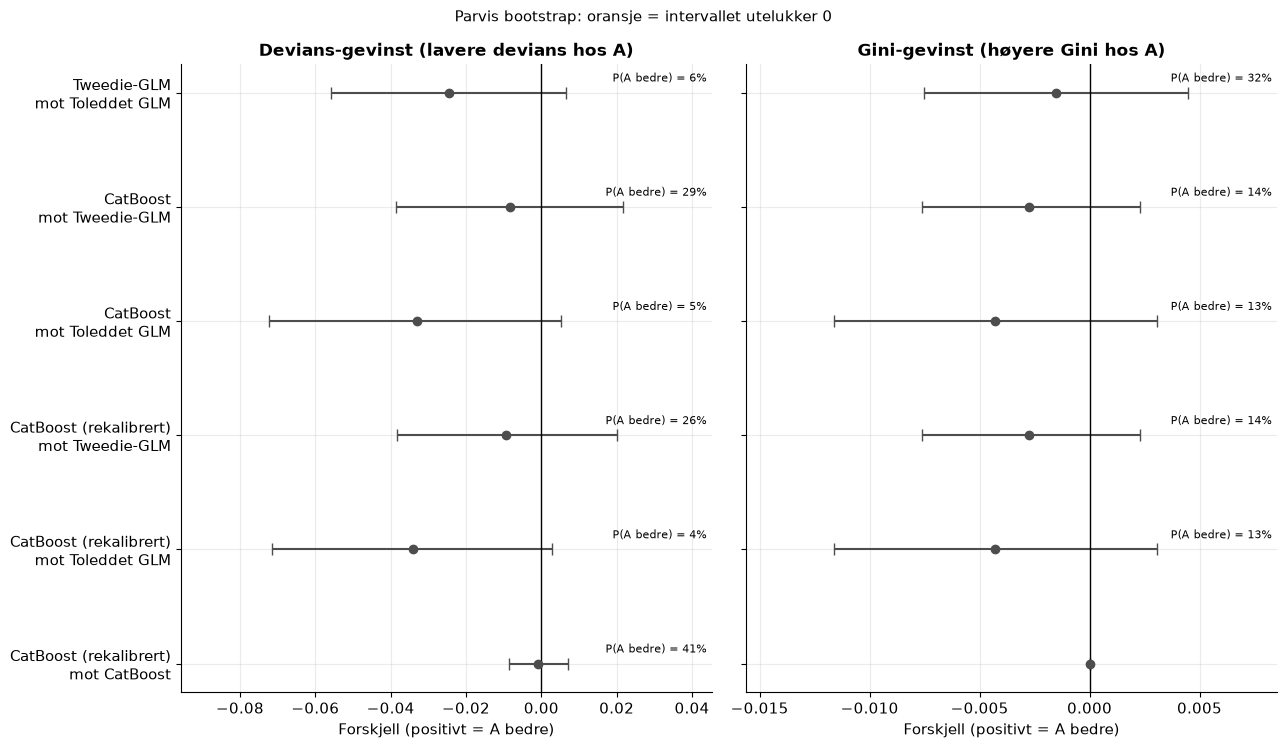

In [7]:
if RUN_2024_EVALUATION:
    figure = plot_pairwise_forest(pairwise)
    display(figure)
    plt.close(figure)

## 5. Begrensninger

- **Ett testår.** Bootstrapen dekker utvalgsvariasjon mellom forsikringstakere innenfor 2024,
  men ikke variasjon fra år til år. Intervallene sier dermed ikke noe om hvordan
  rangeringen ville sett ut i et annet år.
- **Årsdrift.** Alle modeller skåres med 2023-nivået. En prisendring eller endret
  skadenivå fra 2023 til 2024 blir derfor liggende i porteføljebalansen og er ikke en
  modellfeil.
- **Optimistiske utviklingsscorer.** Variabelutvalg, spesifikasjon og hyperparametere er
  valgt på samme fem CV-folder, og $p$ er estimert på hele utviklingssettet.
- **CatBoost og nivå.** Modellen undervurderer porteføljen også på utviklingsdata.
  Nivåfaktoren $c$ er beregnet fra 2022–2023 alene og er en post hoc-variant; den er ikke
  forhåndsspesifisert og påvirker ikke Gini.
- **Klipping.** GLM-ene klipper numeriske prediktorer til treningsområdet, mens trærne er
  flate utenfor området. Det kan gi CatBoost en liten fordel eller ulempe i halene.
- **Lav forklart varians.** Skadekostnad per poliseår har få og skjeve skader; alle
  modeller forklarer bare en liten andel av variasjonen.

## 6. Tolkning

Modellene er evaluert én gang på 2024, og ingenting er justert etter resultatet.

- **Alle modellene slår nullmodellen, og like mye.** $D^2$ er 3,5 % for de tre modellene
  (intervall ca. 3,1–3,9 %) og Gini er 0,295–0,300 (normalisert ca. 0,32). Signalet i
  dataene er svakt, men reelt.
- **Modellene kan ikke skilles fra hverandre.** Toleddet GLM har lavest deviance (32,180
  mot 32,204 for Tweedie-GLM og 32,213 for CatBoost), men alle parvise
  devianceforskjeller har 95 %-intervall som inkluderer 0. Størst er toleddet mot
  CatBoost (0,033, intervall −0,005 til 0,072; $P=95\,\%$ for at toleddet er bedre), som
  ligger på grensen. Gini-forskjellene er høyst 0,004 med intervaller på ca. ±0,006–0,007.
- **CatBoost er den eneste modellen med nivåskjevhet.** Balansen er −4,0 % (intervall
  −7,2 til −0,7 %), mens GLM-ene ligger på +0,9 % og −0,8 %. Nullmodellen (2022–23-snitt)
  ligger −2,6 % under 2024, så noe av skjevheten kan skyldes at 2024 er dyrere, men
  GLM-ene treffer nivået og resten er derfor CatBoost-spesifikk.
- **Rekalibrering løser nivået, ikke rangeringen.** Faktoren $c=1{,}027$ fra
  utviklingsdata flytter balansen fra −4,0 % til −1,4 % (intervallet inkluderer nå 0).
  Gini er uendret, devians endres ikke (32,213 mot 32,214), og vektet MAE går fra 391,4 til
  395,6. Nivået var altså et rent nivåproblem, men rekalibreringen gjør ikke CatBoost bedre
  enn GLM-ene.
- **Alle modeller undervurderer den dyreste tiendedelen.** Observert/predikert er 1,12–1,21
  i øverste prediksjonsdesil. Kalibreringen i de øvrige desilene svinger mye mellom
  modellene, og forskjellene er små i forhold til støyen.

**Konklusjon.** Det finnes ingen statistisk holdbar rangering mellom Tweedie-GLM, toleddet
GLM og CatBoost, verken på deviance eller Gini. CatBoost tilfører ingen målbar rangeringsevne
utover GLM-ene med disse 12 rating-variablene, og har i tillegg nivåskjevhet som må
rekalibreres. Med lik ytelse er en GLM det naturlige valget: den er enklere å forklare,
revidere og få godkjent. Intervallene gjelder utvalgsvariasjon innenfor 2024 og ikke
variasjon mellom år, så «ingen forskjell» skal leses som «ikke påvist», ikke som «bevist lik».